# 02 · Extreme Value Analysis — Valencia DANA 2024

**Author:** Salvador Navas  
**Study area:** Province of Valencia, Spain

This notebook implements the statistical frequency analysis from:
> Navas et al. (2025). *Impact of the DANA 2024 episode on the return period of
> extreme daily precipitation in the Valencia region.*

---

## Scientific objective

The central question is: **what is the return period of the 710 mm/day DANA event at Turís,
and by how much does its inclusion in the historical record alter design-precipitation
estimates for standard return periods (T = 10, 100, 500 years)?**

This requires tackling two methodological challenges simultaneously:

1. **The outlier problem.** A single observation that is 3–10 times larger than the
   previous record has enormous leverage on the fitted distribution. The shape parameter ξ
   of the GEV — which controls the heaviness of the tail — is particularly sensitive.
   Different fitting methods (MLE, L-moments, Bayesian) will give different answers, and
   quantifying that disagreement is essential.

2. **The short-record problem.** Even the longest station (Turís, ~50 years) has
   fewer than 60 annual maxima. Reliable extrapolation to T = 500 years from 50 data
   points demands honest uncertainty quantification, not a single best-estimate number.

---

## Analytical pipeline

```
Annual maxima (AMS)
        │
        ├── Point frequency analysis ──── GEV fit per station
        │         │                         ├── MLE         (maximum likelihood)
        │         │                         ├── L-moments   (robust, fast)
        │         │                         ├── Fisher CI   (asymptotic covariance)
        │         │                         └── MCMC        (full Bayesian posterior)
        │         │
        │         └── WITH DANA vs WITHOUT DANA
        │
        └── Regional frequency analysis ─ Standardise across stations
                  │                         ├── Regional GEV fit
                  │                         └── Back-transform to station scale
                  │
                  └── WITH DANA vs WITHOUT DANA
```

---

## The GEV distribution

The Generalised Extreme Value distribution unifies three families through the shape parameter ξ:

$$F(x;\mu,\sigma,\xi) = \exp\!\left[-\left(1 + \xi\,\frac{x-\mu}{\sigma}\right)^{-1/\xi}\right]$$

| ξ | Family | Tail | Typical application |
|---|--------|------|---------------------|
| **ξ > 0** | Fréchet | Heavy (no upper bound) | Mediterranean convective precipitation |
| **ξ = 0** | Gumbel | Light exponential | Atlantic frontal precipitation |
| **ξ < 0** | Weibull | Bounded above | Sea levels, bounded quantities |

For Mediterranean precipitation, ξ is typically positive (Fréchet domain), meaning
extrapolated return levels grow without bound. A large DANA observation tends to pull
ξ towards higher positive values, amplifying return-level estimates at long periods.

The **return level** for return period T is:
$$z_T = \mu + \frac{\sigma}{\xi}\left[(-\ln(1-1/T))^{-\xi} - 1\right] \quad (\xi \neq 0)$$

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import genextreme
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from pyhydra.climate.time_series import (
    extract_block_maxima,
    fit_gev,
    fit_gev_map,
    fit_gev_fisher,
    fit_gev_mcmc,
    return_level_gev,
    return_levels,
    return_level_ci,
    plot_return_levels,
    plot_diagnostic,
)

# ── Resolve repository root ───────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'valencia_dana'

# ── Analysis parameters ───────────────────────────────────────────────────────
STATIONS = ['8337X', '8309X', '8414A', '8416X', 'V05', 'V17', 'V01', 'c18m111e01', 'c16m244e01']
STATION_NAMES = {
    '8337X': 'Turís',       '8309X': 'Utiel',
    '8414A': 'VLC Airport', '8416X': 'VLC UPV',
    'V05':   'Cheste',      'V17':   'Picassent',
    'V01':   'Pedralba',
    'c18m111e01': 'Chiva',  'c16m244e01': 'Torrent',
}
FOCUS_STATION  = '8337X'
DANA_VALUE     = 710.0
RETURN_PERIODS = [10, 100, 500]

print(f'DATA_ROOT : {DATA_ROOT}')

# ── Writable session output area ──────────────────────────────────────────────
def _session_root_from_cwd() -> Path:
    cwd = Path.cwd().resolve()
    return next(
        (p.parent for p in (cwd, *cwd.parents) if p.name == 'notebooks'),
        cwd / '.hydra_runtime',
    )

SESSION_ROOT = _session_root_from_cwd()
SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'valencia_dana'
SESSION_DATA_ROOT.mkdir(parents=True, exist_ok=True)


def _session_or_shared(relative_path: str | Path) -> Path:
    relative_path = Path(relative_path)
    session_path = SESSION_DATA_ROOT / relative_path
    return session_path if session_path.exists() else DATA_ROOT / relative_path

DATA_ROOT : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana


---
## 1. Load annual maxima and define scenarios

The GEV fitting is run under two **scenarios**, comparing the statistical model fitted on the
historical record with and without the 2024 observation:

| Scenario | Description | Years used |
|----------|-------------|------------|
| **SD** (Sin DANA) | Historical record only, excluding 2024 | up to 2023 |
| **CD** (Con DANA) | Full record including the DANA observation | up to 2024 |

The difference between the two scenarios quantifies the **impact of the DANA event on
design-precipitation estimates** — i.e., how much the distribution shifts when this
extraordinary observation is absorbed into the historical record.

In [3]:
# Valencia session output guard: prefer session artifacts, fall back to shared inputs.
from pathlib import Path
import os
if 'DATA_ROOT' not in globals():
    _cwd = Path.cwd().resolve()
    _candidates = [Path('/workspace'), _cwd, *_cwd.parents]
    REPO_ROOT = next(
        (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
        _cwd,
    )
    DATA_DIR = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
    DATA_ROOT = DATA_DIR / 'pilot_cases' / 'valencia_dana'
if 'SESSION_DATA_ROOT' not in globals():
    _cwd = Path.cwd().resolve()
    SESSION_ROOT = next(
        (p.parent for p in (_cwd, *_cwd.parents) if p.name == 'notebooks'),
        _cwd / '.hydra_runtime',
    )
    SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'valencia_dana'
SESSION_DATA_ROOT.mkdir(parents=True, exist_ok=True)
if '_session_or_shared' not in globals():
    def _session_or_shared(relative_path: str | Path) -> Path:
        relative_path = Path(relative_path)
        session_path = SESSION_DATA_ROOT / relative_path
        return session_path if session_path.exists() else DATA_ROOT / relative_path

# Load pre-computed annual maxima from Notebook 01 (or recompute if not available)
ams_path = _session_or_shared('annual_maxima.csv')
if ams_path.exists():
    ams = pd.read_csv(ams_path, index_col=0)
    ams.index = ams.index.astype(int)
    ams.index.name = 'Year'
    print('Loaded pre-computed annual maxima from Notebook 01.')
else:
    daily = pd.read_csv(
        DATA_ROOT / 'Daily_series_conjuntas_V2.csv',
        index_col=0, parse_dates=True
    )
    avail = [s for s in STATIONS if s in daily.columns]
    ams = daily[avail].resample('YE').max(min_count=1)
    ams.index = ams.index.year
    ams.index.name = 'Year'
    print('Recomputed annual maxima from daily series.')

avail = [s for s in STATIONS if s in ams.columns]

# Scenarios
ams_sd = ams[ams.index < 2024]   # SD: without DANA
ams_cd = ams.copy()               # CD: with DANA

# Focus on Turís
data_sd = ams_sd[FOCUS_STATION].dropna().values.astype(float)
data_cd = ams_cd[FOCUS_STATION].dropna().values.astype(float)

print(f'Period    : {ams.index.min()} – {ams.index.max()}')
print(f'Turís AMS : {len(data_sd)} years (SD)  /  {len(data_cd)} years (CD)')
print(f'DANA obs  : {data_cd.max():.1f} mm  (expected ≈ {DANA_VALUE:.0f} mm)')

Loaded pre-computed annual maxima from Notebook 01.
Period    : 1920 – 2024
Turís AMS : 16 years (SD)  /  17 years (CD)
DANA obs  : 710.8 mm  (expected ≈ 710 mm)


---
## 2. Fitting methods — overview

Four complementary methods are applied. Each makes different trade-offs between robustness,
speed, and information content:

| Method | Approach | Strength | Limitation |
|--------|----------|----------|------------|
| **MLE** | Maximises log-likelihood | Asymptotically efficient; standard | Sensitive to outliers; ξ can diverge for short records |
| **L-moments** | Method of moments via probability-weighted means | Robust to outliers; always converges | No built-in uncertainty; slightly less efficient than MLE |
| **Fisher CI** | MLE + asymptotic covariance (numerical Hessian) | Fast uncertainty; equivalent to delta method | Normal approximation breaks down for very short records or extreme ξ |
| **MCMC** | Full Bayesian posterior via NUTS sampler (PyMC) | Exact uncertainty; incorporates prior information | Slow (minutes); requires PyMC |

**Which method to trust most?**  
When n > 30 and the DANA observation is included, MLE ± Fisher provides a practical first
answer. L-moments gives a robust sanity check — if MLE and L-moments diverge sharply, the
DANA value is distorting the MLE fit. MCMC should be used when the full posterior shape
matters (e.g., for risk-based decision-making with explicit probability of exceedance).

In [4]:
def fit_all(data, label=''):
    """Fit GEV with MLE, L-moments, and Fisher uncertainty; print a compact summary."""
    params_mle     = fit_gev(data, method='mle')
    params_lmom    = fit_gev(data, method='lmom')
    samples_fisher = fit_gev_fisher(data, n_samples=2000)
    print(f'\n{label}')
    print(f'  MLE    : μ={params_mle["mu"]:6.1f}  σ={params_mle["sigma"]:5.1f}  ξ={params_mle["xi"]:+.4f}')
    print(f'  L-mom  : μ={params_lmom["mu"]:6.1f}  σ={params_lmom["sigma"]:5.1f}  ξ={params_lmom["xi"]:+.4f}')
    print(f'  Fisher : μ={samples_fisher["mu"].mean():6.1f} ± {samples_fisher["mu"].std():.1f}  '
          f'σ={samples_fisher["sigma"].mean():.1f} ± {samples_fisher["sigma"].std():.1f}  '
          f'ξ={samples_fisher["xi"].mean():+.3f} ± {samples_fisher["xi"].std():.3f}')
    return params_mle, params_lmom, samples_fisher

print('=== Turís (8337X) — GEV parameter estimates ===')
mle_sd, lmom_sd, fisher_sd = fit_all(data_sd, 'Without DANA (SD)')
mle_cd, lmom_cd, fisher_cd = fit_all(data_cd, 'With DANA (CD)')

=== Turís (8337X) — GEV parameter estimates ===

Without DANA (SD)
  MLE    : μ=  56.1  σ= 21.7  ξ=+0.2154
  L-mom  : μ=  55.7  σ= 23.3  ξ=+0.1688
  Fisher : μ=  56.4 ± 6.5  σ=22.0 ± 5.1  ξ=+0.217 ± 0.265

With DANA (CD)
  MLE    : μ=  55.1  σ= 25.0  ξ=+0.6663
  L-mom  : μ=  53.1  σ= 20.5  ξ=+0.6989
  Fisher : μ=  55.2 ± 7.0  σ=25.1 ± 7.3  ξ=+0.678 ± 0.300


### Reading the parameter table

- **μ (location)**: shifts the whole distribution left or right; approximately the median
  annual maximum. Including DANA should push μ up slightly.
- **σ (scale)**: controls the spread of the distribution; wider record → larger σ.
- **ξ (shape)**: the critical parameter. A positive shift in ξ when DANA is added means
  the fitted tail becomes heavier — all long-period return levels increase, and the increase
  grows with T. Even a small change (e.g., ξ from 0.10 to 0.20) can triple the T=500
  return level.
- **Fisher ± std**: the standard deviation of the Fisher-sampled parameter distribution,
  representing estimation uncertainty. A large σ on ξ signals that the shape parameter is
  poorly constrained — the record is too short to pin down the tail behaviour reliably.

In [5]:
# Return-level table: point estimates from all three methods, both scenarios
def rl_fisher_median(samples, T):
    q = genextreme.ppf(1 - 1/T, -samples['xi'], loc=samples['mu'], scale=samples['sigma'])
    return np.nanmedian(q)

rows = []
for T in RETURN_PERIODS:
    rows.append({
        'T (yr)': T,
        'MLE (SD)':    round(return_level_gev(mle_sd, T), 1),
        'LMom (SD)':   round(return_level_gev(lmom_sd, T), 1),
        'Fisher (SD)': round(rl_fisher_median(fisher_sd, T), 1),
        'MLE (CD)':    round(return_level_gev(mle_cd, T), 1),
        'LMom (CD)':   round(return_level_gev(lmom_cd, T), 1),
        'Fisher (CD)': round(rl_fisher_median(fisher_cd, T), 1),
    })

tbl = pd.DataFrame(rows).set_index('T (yr)')
print('Return levels at Turís (mm) — point estimates:')
print(tbl.to_string())
print('\nΔP: shift in return level due to DANA inclusion (CD − SD):')
for T in RETURN_PERIODS:
    delta = tbl.loc[T, 'MLE (CD)'] - tbl.loc[T, 'MLE (SD)']
    print(f'  T={T:4d} yr : ΔP = +{delta:.1f} mm ({delta/tbl.loc[T,"MLE (SD)"]*100:.0f}%)')

Return levels at Turís (mm) — point estimates:
        MLE (SD)  LMom (SD)  Fisher (SD)  MLE (CD)  LMom (CD)  Fisher (CD)
T (yr)                                                                    
10         119.1      119.6        120.1     185.7      165.3        185.3
100        227.0      218.0        225.3     821.8      755.6        822.1
500        340.0      312.0        333.6    2373.9     2284.4       2412.9

ΔP: shift in return level due to DANA inclusion (CD − SD):
  T=  10 yr : ΔP = +66.6 mm (56%)
  T= 100 yr : ΔP = +594.8 mm (262%)
  T= 500 yr : ΔP = +2033.9 mm (598%)


---
## 3. Return-level plot with uncertainty bands

The return-level plot is the primary diagnostic output of a frequency analysis. It shows:

- **Curves**: GEV return levels as a function of T on a log scale. The curvature reflects ξ:
  a strongly curved line (concave up) means ξ >> 0, a nearly straight line means Gumbel (ξ ≈ 0).
- **Shaded bands**: 95% confidence interval from Fisher samples — the uncertainty in the
  return-level estimates due to finite sample size.
- **Scatter**: empirical plotting positions (Gringorten formula) — the observed data plotted
  at their empirical non-exceedance probability.

**What to look for:**
- How far do the two curves (SD vs CD) separate as T increases? A large separation at T=500
  but small at T=10 indicates that DANA primarily affects the tail rather than the body.
- How wide are the confidence bands? Overlapping bands mean we cannot statistically distinguish
  the two fits — the DANA event's impact is within sampling uncertainty.
- Does the DANA observation (710 mm, red dotted line) fall within the T=2000 extrapolation
  of the pre-DANA curve? If yes, 710 mm was not fundamentally impossible under the old model
  — it was just very rare.

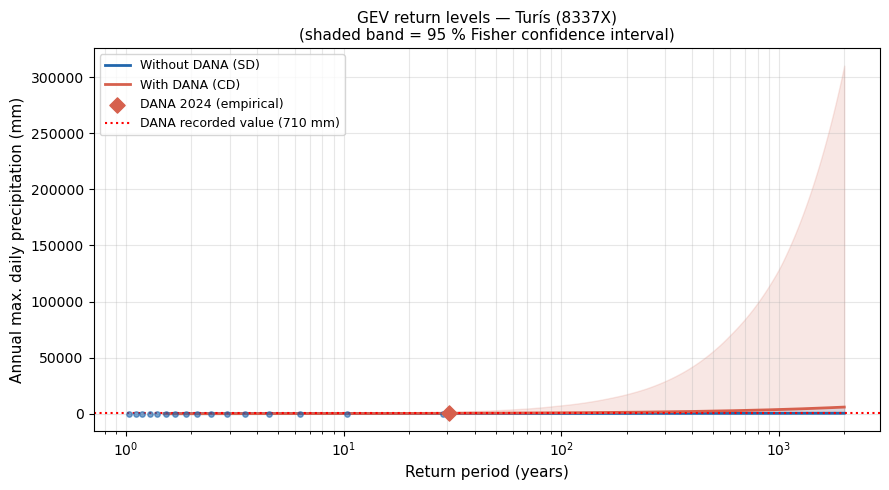

In [6]:
T_range = np.logspace(np.log10(1.5), np.log10(2000), 300)

def gev_rl_curve(params, T_arr):
    return genextreme.ppf(1 - 1/T_arr, -params['xi'], loc=params['mu'], scale=params['sigma'])

def fisher_ci(samples, T_arr, q_lo=0.025, q_hi=0.975):
    """Return lower and upper CI from Fisher parameter samples."""
    q = genextreme.ppf(
        1 - 1/T_arr,
        -samples['xi'].values[:, None],
        loc=samples['mu'].values[:, None],
        scale=samples['sigma'].values[:, None]
    )
    return np.nanquantile(q, q_lo, axis=0), np.nanquantile(q, q_hi, axis=0)

def empirical_positions(data):
    """Gringorten plotting positions → empirical return periods."""
    n  = len(data)
    pp = (np.arange(1, n + 1) - 0.44) / (n + 0.12)
    return 1 / (1 - np.sort(pp)), np.sort(data)

fig, ax = plt.subplots(figsize=(9, 5))

for params, fisher, color, label in [
    (mle_sd, fisher_sd, '#2166ac', 'Without DANA (SD)'),
    (mle_cd, fisher_cd, '#d6604d', 'With DANA (CD)'),
]:
    rl  = gev_rl_curve(params, T_range)
    lo, hi = fisher_ci(fisher, T_range)
    ax.plot(T_range, rl, color=color, lw=2, label=label)
    ax.fill_between(T_range, lo, hi, color=color, alpha=0.15)

# Empirical scatter (both scenarios share the same pre-2024 points; CD adds the 2024 point)
T_emp, P_emp = empirical_positions(data_sd)
ax.scatter(T_emp, P_emp, c='#2166ac', s=15, alpha=0.6, zorder=5)
if len(data_cd) > len(data_sd):
    T_emp_cd, P_emp_cd = empirical_positions(data_cd)
    ax.scatter(T_emp_cd[-1:], P_emp_cd[-1:], c='#d6604d', s=60, zorder=6,
               marker='D', label='DANA 2024 (empirical)')

ax.axhline(DANA_VALUE, color='red', linestyle=':', lw=1.5,
           label=f'DANA recorded value ({DANA_VALUE:.0f} mm)')

ax.set_xscale('log')
ax.set_xlabel('Return period (years)', fontsize=11)
ax.set_ylabel('Annual max. daily precipitation (mm)', fontsize=11)
ax.set_title('GEV return levels — Turís (8337X)\n'
             '(shaded band = 95 % Fisher confidence interval)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Return period of the DANA event

Given the fitted GEV, the return period of the observed value *x* is:
$$T(x) = \frac{1}{1 - F_{\text{GEV}}(x;\hat{\mu},\hat{\sigma},\hat{\xi})}$$

This point estimate depends entirely on the three fitted parameters. Because those parameters
carry uncertainty (captured in the Fisher samples), the return period itself has a distribution.

Two scenarios produce very different answers:
- **Without DANA in the record (SD):** the model is calibrated on a dataset that does *not*
  include 710 mm. The return period estimate reflects what pre-DANA hydrology implied about
  events of this magnitude.
- **With DANA in the record (CD):** 710 mm is now the largest observed value. Its position
  in the tail of the fitted distribution determines the return period. Counterintuitively,
  including DANA often *reduces* its estimated return period (by shifting ξ upward and
  making the tail heavier).

> **Interpretation caveat:** the return period derived from a GEV fit is model-dependent.
> A heavy-tailed fit (large positive ξ) can assign a return period of 100 years to a value
> that a lighter-tailed fit would call a 10,000-year event. The uncertainty bands are
> essential context — report the median and a 90% CI, not just the point estimate.

In [7]:
def return_period_point(params, value):
    """Point estimate of return period for a given observation value."""
    cdf = genextreme.cdf(value, -params['xi'], loc=params['mu'], scale=params['sigma'])
    return 1 / (1 - cdf) if cdf < 1 else np.inf

def return_period_distribution(samples, value):
    """Distribution of return period from Fisher/MCMC parameter samples."""
    cdf  = genextreme.cdf(value, -samples['xi'].values,
                          loc=samples['mu'].values, scale=samples['sigma'].values)
    T_vals = np.where(cdf < 1, 1 / (1 - cdf), np.inf)
    return T_vals[np.isfinite(T_vals) & (T_vals > 0)]

T_pt_sd = return_period_point(mle_sd, DANA_VALUE)
T_pt_cd = return_period_point(mle_cd, DANA_VALUE)
T_dist_sd = return_period_distribution(fisher_sd, DANA_VALUE)
T_dist_cd = return_period_distribution(fisher_cd, DANA_VALUE)

print(f'Return period of {DANA_VALUE:.0f} mm at Turís (MLE point estimate):')
print(f'  Without DANA (SD) : T ≈ {T_pt_sd:.0f} years')
print(f'  With DANA (CD)    : T ≈ {T_pt_cd:.0f} years')
print()
print('Fisher uncertainty on the return period:')
for T_dist, label in [(T_dist_sd, 'Without DANA (SD)'), (T_dist_cd, 'With DANA (CD)')]:
    p5, p50, p95 = np.percentile(T_dist, [5, 50, 95])
    print(f'  {label}: median = {p50:.0f} yr  [90 % CI: {p5:.0f} – {p95:.0f} yr]')

Return period of 710 mm at Turís (MLE point estimate):
  Without DANA (SD) : T ≈ 11397 years
  With DANA (CD)    : T ≈ 80 years

Fisher uncertainty on the return period:
  Without DANA (SD): median = 3529 yr  [90 % CI: 107 – 12479186173 yr]
  With DANA (CD): median = 78 yr  [90 % CI: 18 – 7481 yr]


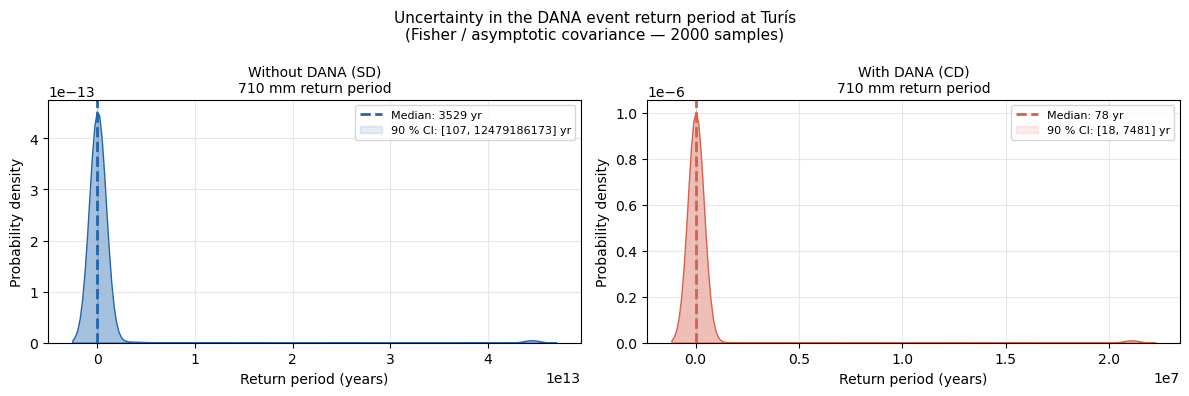

In [8]:
# Density plot: distribution of estimated return period for the DANA event
# The long right tail of these distributions reflects deep uncertainty in ξ.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, T_dist, label, color, T_pt in [
    (axes[0], T_dist_sd, 'Without DANA (SD)', '#2166ac', T_pt_sd),
    (axes[1], T_dist_cd, 'With DANA (CD)',    '#d6604d', T_pt_cd),
]:
    # Clip at 99th percentile to avoid very long tails dominating the plot
    T_plot = np.clip(T_dist, 0, np.percentile(T_dist, 99))
    sns.kdeplot(T_plot, ax=ax, fill=True, color=color, alpha=0.4, bw_adjust=0.8)
    p50 = np.median(T_dist)
    p5, p95 = np.percentile(T_dist, [5, 95])
    ax.axvline(p50, color=color, lw=2, linestyle='--',
               label=f'Median: {p50:.0f} yr')
    ax.axvspan(p5, min(p95, T_plot.max()), alpha=0.12, color=color,
               label=f'90 % CI: [{p5:.0f}, {p95:.0f}] yr')
    ax.set_xlabel('Return period (years)', fontsize=10)
    ax.set_ylabel('Probability density', fontsize=10)
    ax.set_title(f'{label}\n{DANA_VALUE:.0f} mm return period', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Uncertainty in the DANA event return period at Turís\n'
             '(Fisher / asymptotic covariance — 2000 samples)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5. GEV goodness-of-fit diagnostics

Before using the fitted GEV for design purposes, standard diagnostics check whether the
model is a plausible representation of the data:

| Plot | What to look for | Red flag |
|------|-----------------|----------|
| **PP plot** (probability–probability) | Points on the 1:1 diagonal | Systematic S-curve → wrong tail weight |
| **QQ plot** (quantile–quantile) | Points on the 1:1 diagonal | Large deviation at upper tail → ξ misfit |
| **Return level plot** | Empirical points inside CI band | Points outside CI → unexplained structure |
| **Density overlay** | GEV pdf tracks histogram shape | Histogram multi-modal → mixture needed |

The most critical check is the **upper QQ plot tail**: if the DANA observation (rightmost
point) sits far above the fitted line, the GEV underestimates the tail — either ξ is too
small, or the data does not follow a simple GEV. Including DANA in the CD fit should
bring that rightmost point closer to the diagonal.

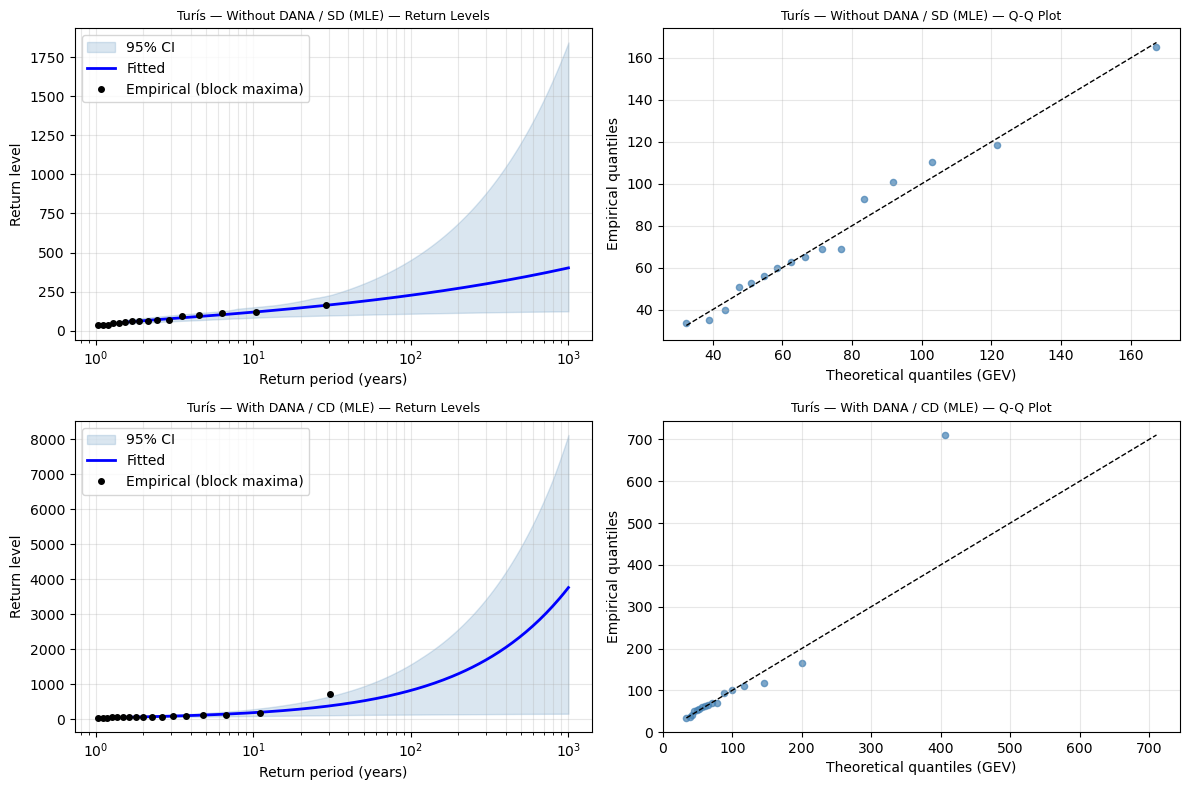

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_diagnostic(data_sd, mle_sd, dist='gev',
                title='Turís — Without DANA / SD (MLE)',
                axes=axes[0])
plot_diagnostic(data_cd, mle_cd, dist='gev',
                title='Turís — With DANA / CD (MLE)',
                axes=axes[1])
plt.tight_layout()
plt.show()

---
## 6. Full Bayesian posterior (MCMC)

The Fisher CI is based on a normal approximation of the parameter posterior — it becomes
unreliable when:
- The record is short (< 25 years)
- ξ is large and positive (right-skewed posterior)
- The likelihood surface is non-quadratic (common with outliers like DANA)

**MCMC** (Markov Chain Monte Carlo via PyMC/NUTS) samples the *exact* posterior distribution
without any Gaussian approximation. It is slower (minutes vs seconds) but provides:
- The full posterior shape — asymmetric tails, multi-modality if present
- Proper credible intervals (not approximate)
- Comparison across priors — weakly informative priors regularise extreme ξ estimates

**Priors used here** (weakly informative, same as Valencia-Study paper):
- μ: Normal(y̅, s) via non-centred parameterisation
- σ: LogNormal(log(s), 1) — ensures positivity, allows wide range
- ξ: TruncatedNormal(0, 0.5, −1, 1) — regularises extreme shape towards 0 without
  ruling out heavy tails; consistent with published literature on Mediterranean precipitation

In [10]:
try:
    import pymc
    RUN_MCMC = True
    print(f'PyMC {pymc.__version__} available — MCMC sections will run.')
    print('Note: sampling takes ~2–5 minutes per scenario.')
except ImportError:
    RUN_MCMC = False
    print('PyMC not installed — MCMC sections skipped.')
    print('Install with: pip install pymc')
    print('Fisher CI results (Section 2–4) remain fully valid.')

PyMC 6.0.1 available — MCMC sections will run.
Note: sampling takes ~2–5 minutes per scenario.


In [11]:
if RUN_MCMC:
    print('Sampling WITHOUT DANA (SD)...')
    mcmc_sd = fit_gev_mcmc(data_sd, n_samples=1000, n_chains=4, adapt_delta=0.95)
    print('\nSampling WITH DANA (CD)...')
    mcmc_cd = fit_gev_mcmc(data_cd, n_samples=1000, n_chains=4, adapt_delta=0.95)

    print('\n=== Posterior summary — Without DANA (SD) ===')
    print(mcmc_sd.describe().round(3))
    print('\n=== Posterior summary — With DANA (CD) ===')
    print(mcmc_cd.describe().round(3))

Sampling WITHOUT DANA (SD)...
                                                                                
                                  Step    Grad                                  
  Progress        Draw    Dive…   size    evals   Speed          Elap…   Rema…  
 ────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━   2000    1       0.328   15      3880.60 dra…   0:00…   0:00…  
  ━━━━━━━━━━━━━   2000    0       0.000   1023    66.16 draws…   0:00…   0:00…  
  ━━━━━━━━━━━━━   2000    5       0.226   7       3822.84 dra…   0:00…   0:00…  
  ━━━━━━━━━━━━━   2000    686     0.072   63      815.04 draw…   0:00…   0:00…  
                                                                                

Sampling WITH DANA (CD)...
                                                                                
                                  Step    Grad                                  
  Progress        Draw    Dive…   size    evals   S

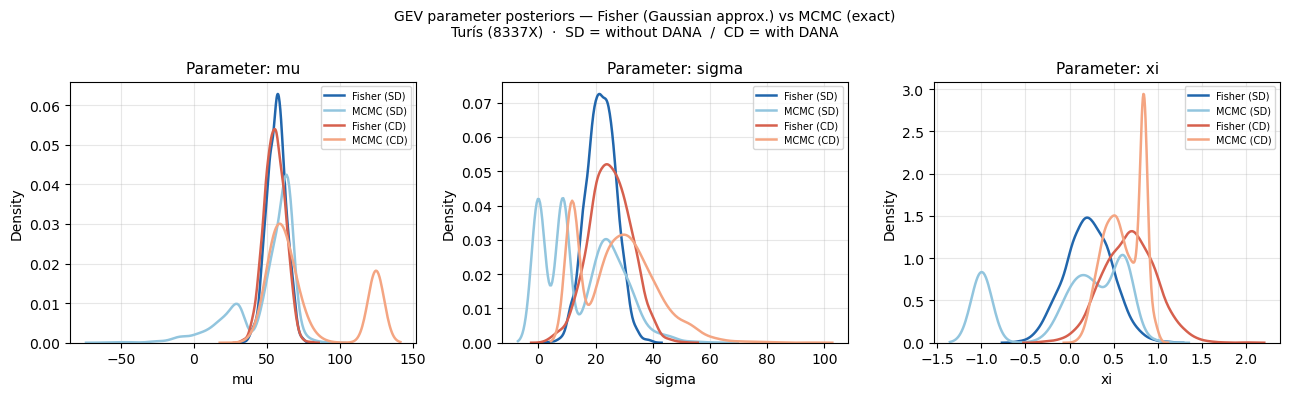

In [12]:
if RUN_MCMC:
    # Parameter posterior: Fisher vs MCMC
    # Divergence between Fisher (Gaussian approx) and MCMC (exact) reveals
    # whether the normal approximation is adequate for this dataset.
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for i, p in enumerate(['mu', 'sigma', 'xi']):
        ax = axes[i]
        for samp, lbl, col in [
            (fisher_sd, 'Fisher (SD)', '#2166ac'), (mcmc_sd, 'MCMC (SD)', '#92c5de'),
            (fisher_cd, 'Fisher (CD)', '#d6604d'), (mcmc_cd, 'MCMC (CD)', '#f4a582'),
        ]:
            sns.kdeplot(samp[p], ax=ax, label=lbl, color=col, lw=1.8)
        ax.set_title(f'Parameter: {p}', fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    plt.suptitle('GEV parameter posteriors — Fisher (Gaussian approx.) vs MCMC (exact)\n'
                 'Turís (8337X)  ·  SD = without DANA  /  CD = with DANA', fontsize=10)
    plt.tight_layout()
    plt.show()

In [13]:
if RUN_MCMC:
    # MCMC return period of DANA event
    T_mcmc_sd = return_period_distribution(mcmc_sd, DANA_VALUE)
    T_mcmc_cd = return_period_distribution(mcmc_cd, DANA_VALUE)

    print('MCMC return period of the DANA event at Turís:')
    for T_dist, label in [(T_mcmc_sd, 'Without DANA (SD)'), (T_mcmc_cd, 'With DANA (CD)')]:
        p5, p50, p95 = np.percentile(T_dist, [5, 50, 95])
        print(f'  {label}: median = {p50:.0f} yr  [90 % CI: {p5:.0f} – {p95:.0f} yr]')

    print('\nComparison: Fisher vs MCMC (median, 90% CI):')
    for T_fish, T_mcmc, label in [
        (T_dist_sd, T_mcmc_sd, 'SD'), (T_dist_cd, T_mcmc_cd, 'CD')
    ]:
        f5, f50, f95 = np.percentile(T_fish, [5, 50, 95])
        m5, m50, m95 = np.percentile(T_mcmc, [5, 50, 95])
        print(f'  {label}: Fisher [{f5:.0f}–{f95:.0f}] yr  vs  MCMC [{m5:.0f}–{m95:.0f}] yr')

MCMC return period of the DANA event at Turís:
  Without DANA (SD): median = 507 yr  [90 % CI: 118 – 287639380 yr]
  With DANA (CD): median = 90 yr  [90 % CI: 27 – 1143 yr]

Comparison: Fisher vs MCMC (median, 90% CI):
  SD: Fisher [107–12479186173] yr  vs  MCMC [118–287639380] yr
  CD: Fisher [18–7481] yr  vs  MCMC [27–1143] yr


---
## 7. Multi-station point analysis

Running the GEV fit at all 9 stations allows us to check whether the DANA impact is
consistent across the network or concentrated at a few stations.

Expected pattern:
- Stations close to Turís (Chiva, Torrent, Picassent) should show the largest ΔP
  because they also recorded very high DANA values.
- Distant stations (Valencia Airport, Utiel) should show smaller shifts — the DANA
  event was spatially concentrated in the Turís–Chiva corridor.

In [14]:
results_point = []

for st in avail:
    for scenario, df_ams in [('Without DANA', ams_sd), ('With DANA', ams_cd)]:
        data = df_ams[st].dropna().values.astype(float)
        if len(data) < 10:
            print(f'  Skip {st} / {scenario}: only {len(data)} years')
            continue
        try:
            params_mle  = fit_gev(data, method='mle')
            params_lmom = fit_gev(data, method='lmom')
            fisher_s    = fit_gev_fisher(data, n_samples=1000)
        except Exception as e:
            print(f'  Fitting failed {st}/{scenario}: {e}')
            continue

        row = {
            'Station': STATION_NAMES.get(st, st), 'ID': st,
            'Scenario': scenario, 'N': len(data),
            'xi_mle': round(params_mle['xi'], 3),
        }
        for T in RETURN_PERIODS:
            q = genextreme.ppf(1 - 1/T, -fisher_s['xi'].values,
                               loc=fisher_s['mu'].values, scale=fisher_s['sigma'].values)
            row[f'T{T}_mle']  = round(return_level_gev(params_mle, T), 1)
            row[f'T{T}_lmom'] = round(return_level_gev(params_lmom, T), 1)
            row[f'T{T}_p025'] = round(np.nanquantile(q, 0.025), 1)
            row[f'T{T}_p975'] = round(np.nanquantile(q, 0.975), 1)
        results_point.append(row)

results_point = pd.DataFrame(results_point)
print(results_point[['Station', 'Scenario', 'N', 'xi_mle',
                       'T10_mle', 'T100_mle', 'T500_mle']].to_string(index=False))

  Station     Scenario  N  xi_mle  T10_mle  T100_mle  T500_mle
    Turís Without DANA 16   0.215    119.1     227.0     340.0
    Turís    With DANA 17   0.666    185.7     821.8    2373.9
  VLC UPV Without DANA 18   0.274    103.3     216.6     349.4
  VLC UPV    With DANA 19   0.271    100.6     208.4     333.9
   Cheste Without DANA 24   0.421    107.8     282.3     552.2
   Cheste    With DANA 25   0.446    115.7     320.9     653.9
Picassent Without DANA 23   0.028    131.2     207.0     262.0
Picassent    With DANA 24  -0.003    133.0     203.6     251.8
 Pedralba Without DANA 24   0.371    116.3     291.4     538.0
 Pedralba    With DANA 25   0.459    133.7     397.9     836.8
    Chiva Without DANA 15   0.294    106.8     227.9     375.3
    Chiva    With DANA 16   0.694    162.5     761.0    2298.2
  Torrent Without DANA 16   0.115    101.1     170.2     229.7
  Torrent    With DANA 17   0.044    100.1     160.5     205.7


In [15]:
# ΔP across all stations — how much does DANA shift T=100 yr return levels?
print('=== ΔP (mm) due to DANA inclusion — MLE return levels ===')
for T in RETURN_PERIODS:
    pivot = results_point.pivot(index='Station', columns='Scenario', values=f'T{T}_mle')
    pivot.columns.name = None
    pivot['ΔP (mm)'] = (pivot.get('With DANA', np.nan) -
                         pivot.get('Without DANA', np.nan)).round(1)
    print(f'\nT = {T} years:')
    print(pivot.round(1)[['Without DANA', 'With DANA', 'ΔP (mm)']].to_string())

=== ΔP (mm) due to DANA inclusion — MLE return levels ===

T = 10 years:
           Without DANA  With DANA  ΔP (mm)
Station                                    
Cheste            107.8      115.7      7.9
Chiva             106.8      162.5     55.7
Pedralba          116.3      133.7     17.4
Picassent         131.2      133.0      1.8
Torrent           101.1      100.1     -1.0
Turís             119.1      185.7     66.6
VLC UPV           103.3      100.6     -2.7

T = 100 years:
           Without DANA  With DANA  ΔP (mm)
Station                                    
Cheste            282.3      320.9     38.6
Chiva             227.9      761.0    533.1
Pedralba          291.4      397.9    106.5
Picassent         207.0      203.6     -3.4
Torrent           170.2      160.5     -9.7
Turís             227.0      821.8    594.8
VLC UPV           216.6      208.4     -8.2

T = 500 years:
           Without DANA  With DANA  ΔP (mm)
Station                                    
Cheste         

---
## 8. Regional Frequency Analysis (RFA)

### Motivation

Point frequency analysis uses only the data from a single station. When records are short
(< 30–40 years, as for most SIAR and AVAMET stations here), the GEV parameters — especially
ξ — are poorly constrained, leading to very wide confidence intervals.

**Regional Frequency Analysis** addresses this by **pooling data from multiple stations**,
trading spatial homogeneity for increased sample size. The key assumption is:

> *All stations in the region share the same GEV shape (ξ) and scale (σ/μ, the
> coefficient of variation), differing only in their location parameter μ (the "index").*

### Index-flood method (standardised series)

The implementation used here follows the standardisation approach:

1. **Standardise** each station's AMS to zero mean and unit variance using `StandardScaler`:
   $$y_i^{(s)} = \frac{x_i^{(s)} - \bar{x}^{(s)}}{\text{std}(x^{(s)})}$$
2. **Pool**: take the annual maximum across all standardised stations:
   $$y_i^{\text{reg}} = \max_s y_i^{(s)}$$
3. **Fit** a single GEV to the pooled regional series $y^{\text{reg}}$
4. **Back-transform** quantiles to any target station $s$ using its mean and std:
   $$z_T^{(s)} = z_T^{\text{reg}} \cdot \text{std}(x^{(s)}) + \bar{x}^{(s)}$$

**Advantages:**
- More data points → better-constrained ξ → narrower CI
- Short records (AVAMET stations with only 10–15 years) contribute without dominating

**Limitations:**
- Assumes homogeneity: if the precipitation mechanisms differ across stations (e.g.,
  orographic vs coastal), the pooled distribution may not be representative
- The DANA event at Turís (a localised maximum) inflates the regional pooled maximum
  disproportionately, which is statistically valid but may overstate the regional impact

In [16]:
def regional_gev_fit(ams_df, stations, n_fisher=2000):
    """
    Standardise each station's AMS, pool by taking the annual maximum of standardised
    values, fit GEV to the pooled series, and return fitted parameters + Fisher samples.

    Returns
    -------
    scaler, regional_std, params_mle, params_lmom, fisher_samples
    """
    cols = [s for s in stations if s in ams_df.columns]
    sub  = ams_df[cols].dropna(how='all')

    # Standardise: subtract mean, divide by std, per station
    scaler = StandardScaler()
    std_df = pd.DataFrame(
        scaler.fit_transform(sub), index=sub.index, columns=sub.columns
    )
    # Regional series: annual max of standardised values
    regional_std = std_df.max(axis=1).dropna().values

    params_mle  = fit_gev(regional_std, method='mle')
    params_lmom = fit_gev(regional_std, method='lmom')
    fisher_samp = fit_gev_fisher(regional_std, n_samples=n_fisher)

    print(f'Regional N = {len(regional_std)} years')
    print(f'MLE   : μ={params_mle["mu"]:.3f}  σ={params_mle["sigma"]:.3f}  ξ={params_mle["xi"]:+.4f}')
    print(f'L-mom : μ={params_lmom["mu"]:.3f}  σ={params_lmom["sigma"]:.3f}  ξ={params_lmom["xi"]:+.4f}')
    return scaler, regional_std, params_mle, params_lmom, fisher_samp

print('--- Regional fit WITHOUT DANA (SD) ---')
scaler_sd, reg_sd, params_reg_sd, lmom_reg_sd, fish_reg_sd = regional_gev_fit(ams_sd, avail)

print('\n--- Regional fit WITH DANA (CD) ---')
scaler_cd, reg_cd, params_reg_cd, lmom_reg_cd, fish_reg_cd = regional_gev_fit(ams_cd, avail)

--- Regional fit WITHOUT DANA (SD) ---
Regional N = 24 years
MLE   : μ=0.199  σ=0.773  ξ=+0.1822
L-mom : μ=0.209  σ=0.851  ξ=+0.1023

--- Regional fit WITH DANA (CD) ---
Regional N = 25 years
MLE   : μ=0.186  σ=0.783  ξ=+0.2715
L-mom : μ=0.222  σ=0.892  ξ=+0.1324


In [17]:
# Back-transform regional quantiles to Turís scale
st_idx = avail.index(FOCUS_STATION)

def reg_to_station(params, scaler, idx, T):
    """Regional GEV quantile → station scale."""
    return return_level_gev(params, T) * scaler.scale_[idx] + scaler.mean_[idx]

def reg_fisher_samples(fish, scaler, idx, T_arr):
    """Fisher regional samples → station scale for each T."""
    q_std = genextreme.ppf(
        1 - 1/np.asarray(T_arr),
        -fish['xi'].values[:, None],
        loc=fish['mu'].values[:, None],
        scale=fish['sigma'].values[:, None]
    )  # shape: (n_samples, len(T_arr))
    return q_std * scaler.scale_[idx] + scaler.mean_[idx]

print('Regional return levels at Turís (back-transformed to original scale):')
reg_rows = []
for T in RETURN_PERIODS:
    rl_sd = reg_to_station(params_reg_sd, scaler_sd, st_idx, T)
    rl_cd = reg_to_station(params_reg_cd, scaler_cd, st_idx, T)
    q_sd  = reg_fisher_samples(fish_reg_sd, scaler_sd, st_idx, [T]).flatten()
    q_cd  = reg_fisher_samples(fish_reg_cd, scaler_cd, st_idx, [T]).flatten()
    reg_rows.append({
        'T (yr)': T,
        'RFA MLE (SD)': round(rl_sd, 1),
        'RFA 95CI (SD)': f'[{np.nanquantile(q_sd,0.025):.0f}–{np.nanquantile(q_sd,0.975):.0f}]',
        'RFA MLE (CD)': round(rl_cd, 1),
        'RFA 95CI (CD)': f'[{np.nanquantile(q_cd,0.025):.0f}–{np.nanquantile(q_cd,0.975):.0f}]',
        'ΔP (mm)': round(rl_cd - rl_sd, 1),
    })

print(pd.DataFrame(reg_rows).set_index('T (yr)').to_string())

Regional return levels at Turís (back-transformed to original scale):
        RFA MLE (SD) RFA 95CI (SD)  RFA MLE (CD) RFA 95CI (CD)  ΔP (mm)
T (yr)                                                                 
10             154.3     [118–209]         513.0     [315–828]    358.7
100            271.3     [151–756]        1241.3    [500–4426]    970.0
500            386.1    [164–2021]        2090.1   [580–14079]   1704.0


---
## 9. Point vs Regional — combined return-level plot

Placing point and regional curves on the same axes reveals whether pooling reduces
uncertainty and changes the central estimate:

- **Narrower CI** in the regional curve indicates that pooling was beneficial — the
  regional estimate is more precise than the point estimate.
- If the **central estimates diverge**, it suggests a violation of the homogeneity
  assumption: Turís may have a different tail behaviour than the average of the network.
- In the WITH-DANA scenario, the regional curve absorbs the DANA signal from Turís
  (which dominates the standardised regional maximum in 2024) and redistributes it
  across all stations — this is both the strength and the known limitation of RFA.

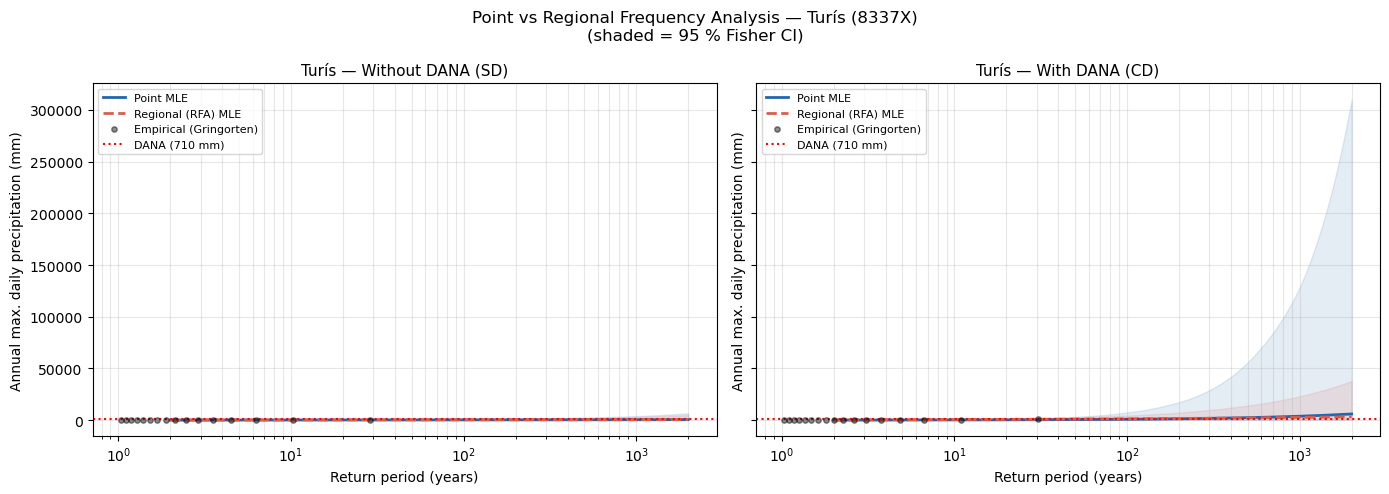

In [18]:
T_plot = np.logspace(np.log10(2), np.log10(2000), 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

scenarios_plot = [
    (axes[0], 'Without DANA (SD)', mle_sd, fisher_sd,
     params_reg_sd, fish_reg_sd, scaler_sd, data_sd),
    (axes[1], 'With DANA (CD)',    mle_cd, fisher_cd,
     params_reg_cd, fish_reg_cd, scaler_cd, data_cd),
]

for ax, title, mle_pt, fish_pt, mle_reg, fish_reg, scaler, data_obs in scenarios_plot:
    # Point MLE + Fisher CI
    rl_pt = gev_rl_curve(mle_pt, T_plot)
    lo_pt, hi_pt = fisher_ci(fish_pt, T_plot)
    ax.plot(T_plot, rl_pt, color='#2166ac', lw=2, label='Point MLE')
    ax.fill_between(T_plot, lo_pt, hi_pt, color='#2166ac', alpha=0.12)

    # Regional MLE + Fisher CI (back-transformed to station scale)
    rl_reg = gev_rl_curve(mle_reg, T_plot) * scaler.scale_[st_idx] + scaler.mean_[st_idx]
    q_reg  = reg_fisher_samples(fish_reg, scaler, st_idx, T_plot)
    lo_reg, hi_reg = np.nanquantile(q_reg, 0.025, axis=0), np.nanquantile(q_reg, 0.975, axis=0)
    ax.plot(T_plot, rl_reg, color='#d6604d', lw=2, linestyle='--', label='Regional (RFA) MLE')
    ax.fill_between(T_plot, lo_reg, hi_reg, color='#d6604d', alpha=0.12)

    # Empirical observations
    T_emp, P_emp = empirical_positions(data_obs)
    ax.scatter(T_emp, P_emp, c='k', s=15, alpha=0.45, zorder=5, label='Empirical (Gringorten)')

    ax.axhline(DANA_VALUE, color='red', linestyle=':', lw=1.5,
               label=f'DANA ({DANA_VALUE:.0f} mm)')
    ax.set_xscale('log')
    ax.set_xlabel('Return period (years)', fontsize=10)
    ax.set_ylabel('Annual max. daily precipitation (mm)', fontsize=10)
    ax.set_title(f'Turís — {title}', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Point vs Regional Frequency Analysis — Turís (8337X)\n'
             '(shaded = 95 % Fisher CI)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. ΔP and ΔT — quantifying the DANA impact

Two complementary metrics describe how the DANA event shifts frequency estimates:

**ΔP (precipitation shift):** For a fixed return period T, how much larger is the design
precipitation after including DANA?
$$\Delta P(T) = z_T^{\text{CD}} - z_T^{\text{SD}}$$

**ΔT (return period shift):** For the design precipitation of the pre-DANA era ($z_T^{\text{SD}}$),
what return period does it now correspond to under the updated (CD) model?
$$\Delta T(T) = T^{\text{CD}}(z_T^{\text{SD}}) - T$$
A positive ΔT means that a value previously associated with a T-year event now appears less
rare — it happens more often under the updated distributional model.

The arrow plot below visualises both: horizontal arrows show ΔP (same T, different P) and
vertical arrows show ΔT (same P, different T).

In [19]:
summary_rows = []
for T in RETURN_PERIODS:
    P_sd = return_level_gev(mle_sd, T)
    P_cd = return_level_gev(mle_cd, T)

    cdf_val = genextreme.cdf(P_sd, -mle_cd['xi'], loc=mle_cd['mu'], scale=mle_cd['sigma'])
    T_cd_equiv = 1 / (1 - cdf_val) if 0 < cdf_val < 1 else np.inf

    P_reg_sd = reg_to_station(params_reg_sd, scaler_sd, st_idx, T)
    P_reg_cd = reg_to_station(params_reg_cd, scaler_cd, st_idx, T)

    summary_rows.append({
        'T (yr)': T,
        'Point P (SD)': round(P_sd, 1),
        'Point P (CD)': round(P_cd, 1),
        'Point ΔP': round(P_cd - P_sd, 1),
        'Point T_CD': round(T_cd_equiv, 0),
        'Point ΔT': round(T_cd_equiv - T, 0),
        'RFA P (SD)': round(P_reg_sd, 1),
        'RFA P (CD)': round(P_reg_cd, 1),
        'RFA ΔP': round(P_reg_cd - P_reg_sd, 1),
    })

summary = pd.DataFrame(summary_rows).set_index('T (yr)')
print('Impact of DANA on return levels and return periods at Turís:')
print(summary.to_string())

Impact of DANA on return levels and return periods at Turís:
        Point P (SD)  Point P (CD)  Point ΔP  Point T_CD  Point ΔT  RFA P (SD)  RFA P (CD)  RFA ΔP
T (yr)                                                                                            
10             119.1         185.7      66.6         5.0      -5.0       154.3       513.0   358.7
100            227.0         821.8     594.8        14.0     -86.0       271.3      1241.3   970.0
500            340.0        2373.9    2033.9        26.0    -474.0       386.1      2090.1  1704.0


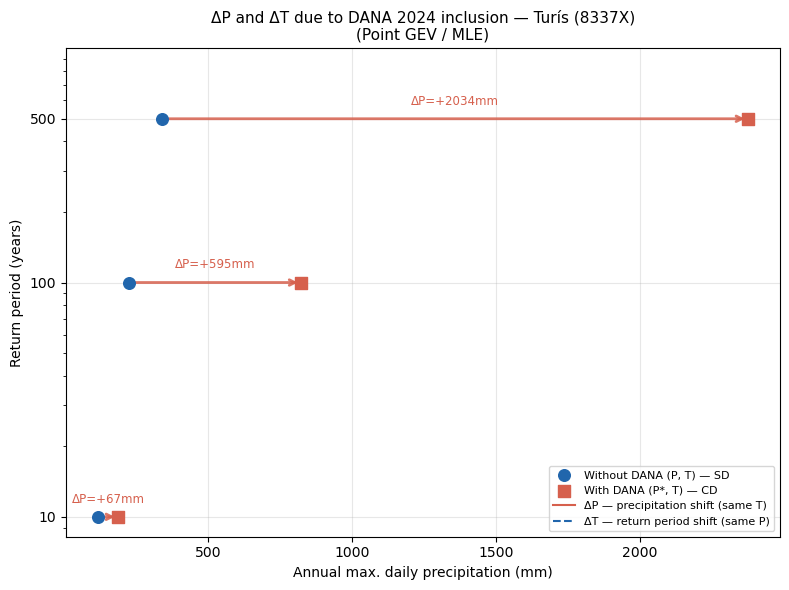

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

for row in summary_rows:
    T = row['T (yr)']
    P_sd, P_cd = row['Point P (SD)'], row['Point P (CD)']
    T_cd = row['Point T_CD']

    # Horizontal arrow → ΔP (precipitation shift at fixed return period)
    ax.annotate('', xy=(P_cd, T), xytext=(P_sd, T),
                arrowprops=dict(arrowstyle='->', color='#d6604d', lw=2.0, alpha=0.85))
    ax.text((P_sd + P_cd) / 2, T * 1.15,
            f'ΔP=+{row["Point ΔP"]:.0f}mm', color='#d6604d',
            ha='center', fontsize=8.5)

    # Vertical arrow ↑ ΔT (return period shift for the pre-DANA design value)
    if np.isfinite(T_cd) and T_cd > T:
        ax.annotate('', xy=(P_sd, T_cd), xytext=(P_sd, T),
                    arrowprops=dict(arrowstyle='->', color='#2166ac',
                                    linestyle='dashed', lw=2.0, alpha=0.85))
        ax.text(P_sd * 1.015, (T + T_cd) / 2,
                f'ΔT=+{row["Point ΔT"]:.0f}yr', color='#2166ac',
                va='center', fontsize=8.5, rotation=90)

    ax.scatter([P_sd], [T], c='#2166ac', s=70, zorder=6)
    ax.scatter([P_cd], [T], c='#d6604d', s=70, marker='s', zorder=6)

ax.scatter([], [], c='#2166ac', s=70, label='Without DANA (P, T) — SD')
ax.scatter([], [], c='#d6604d', s=70, marker='s', label='With DANA (P*, T) — CD')
ax.annotate('', xy=(0, 0), xytext=(1, 0),  # dummy for legend
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.5))
ax.plot([], [], color='#d6604d', lw=1.5, label='ΔP — precipitation shift (same T)')
ax.plot([], [], color='#2166ac', lw=1.5, linestyle='--', label='ΔT — return period shift (same P)')

ax.set_xlabel('Annual max. daily precipitation (mm)', fontsize=10)
ax.set_ylabel('Return period (years)', fontsize=10)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_yticks(RETURN_PERIODS)
ax.set_ylim(top=1000)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
ax.set_title('ΔP and ΔT due to DANA 2024 inclusion — Turís (8337X)\n'
             '(Point GEV / MLE)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 11. Final results table

The table below consolidates all methods and scenarios for Turís, formatted as in the
paper. The four analysis types are:

| Type | Method | Interpretation |
|------|--------|----------------|
| **Point** | Per-station GEV | Local frequency estimate; sensitive to outliers |
| **Regional (RFA)** | Pooled, standardised GEV | Regionally smoothed; tighter CI but homogeneity assumed |

In [21]:
final_rows = []
for T in RETURN_PERIODS:
    for analysis, scenario, params, lmom, fish, scaler in [
        ('Point',          'Without DANA', mle_sd,       lmom_sd,       fisher_sd,   None),
        ('Point',          'With DANA',    mle_cd,       lmom_cd,       fisher_cd,   None),
        ('Regional (RFA)', 'Without DANA', params_reg_sd, lmom_reg_sd,  fish_reg_sd, scaler_sd),
        ('Regional (RFA)', 'With DANA',    params_reg_cd, lmom_reg_cd,  fish_reg_cd, scaler_cd),
    ]:
        if analysis == 'Point':
            rl_mle  = return_level_gev(params, T)
            rl_lmom = return_level_gev(lmom, T)
            q = genextreme.ppf(1-1/T, -fish['xi'], loc=fish['mu'], scale=fish['sigma'])
        else:
            rl_mle  = reg_to_station(params, scaler, st_idx, T)
            rl_lmom = reg_to_station(lmom, scaler, st_idx, T)
            q = reg_fisher_samples(fish, scaler, st_idx, [T]).flatten()

        final_rows.append({
            'T (yr)': T, 'Analysis': analysis, 'Scenario': scenario,
            'MLE': round(rl_mle, 1),
            'L-Moments': round(rl_lmom, 1),
            'Fisher p2.5':  round(np.nanquantile(q, 0.025), 1),
            'Fisher p50':   round(np.nanmedian(q), 1),
            'Fisher p97.5': round(np.nanquantile(q, 0.975), 1),
        })

final_df = pd.DataFrame(final_rows)
print(f'=== Return levels at Turís ({FOCUS_STATION}) — all methods and scenarios ===')
print(final_df.to_string(index=False))

=== Return levels at Turís (8337X) — all methods and scenarios ===
 T (yr)       Analysis     Scenario    MLE  L-Moments  Fisher p2.5  Fisher p50  Fisher p97.5
     10          Point Without DANA  119.1      119.6         82.8       120.1         177.6
     10          Point    With DANA  185.7      165.3         89.4       185.3         432.7
     10 Regional (RFA) Without DANA  154.3      154.7        118.1       154.8         208.9
     10 Regional (RFA)    With DANA  513.0      504.2        315.1       507.4         828.2
    100          Point Without DANA  227.0      218.0        110.5       225.3         773.9
    100          Point    With DANA  821.8      755.6        168.2       822.1        7474.7
    100 Regional (RFA) Without DANA  271.3      252.1        150.6       270.8         756.3
    100 Regional (RFA)    With DANA 1241.3     1012.3        500.2      1209.9        4426.0
    500          Point Without DANA  340.0      312.0        119.7       333.6        2415.3
   

In [22]:
# Valencia session output guard: keep generated files in writable Jupyter session storage.
from pathlib import Path
if 'SESSION_DATA_ROOT' not in globals():
    _cwd = Path.cwd().resolve()
    SESSION_ROOT = next(
        (p.parent for p in (_cwd, *_cwd.parents) if p.name == 'notebooks'),
        _cwd / '.hydra_runtime',
    )
    SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'valencia_dana'
SESSION_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# Save outputs
final_df.to_csv(SESSION_DATA_ROOT / 'results_return_levels.csv', index=False)
results_point.to_csv(SESSION_DATA_ROOT / 'results_point_all_stations.csv', index=False)

print('Results saved:')
print(f'  {SESSION_DATA_ROOT / "results_return_levels.csv"}')
print(f'  {SESSION_DATA_ROOT / "results_point_all_stations.csv"}')
print(f'\nKey findings (Turís, MLE):')
print(f'  Return period of {DANA_VALUE:.0f} mm WITHOUT DANA in record: ~{T_pt_sd:.0f} years')
print(f'  Return period of {DANA_VALUE:.0f} mm WITH DANA in record   : ~{T_pt_cd:.0f} years')
for row in summary_rows:
    T = row['T (yr)']
    print(f'  T={T:4d} yr: ΔP = +{row["Point ΔP"]:.0f} mm, ΔT = +{row["Point ΔT"]:.0f} yr  (Point/MLE)')

Results saved:
  /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/results_return_levels.csv
  /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/valencia_dana/results_point_all_stations.csv

Key findings (Turís, MLE):
  Return period of 710 mm WITHOUT DANA in record: ~11397 years
  Return period of 710 mm WITH DANA in record   : ~80 years
  T=  10 yr: ΔP = +67 mm, ΔT = +-5 yr  (Point/MLE)
  T= 100 yr: ΔP = +595 mm, ΔT = +-86 yr  (Point/MLE)
  T= 500 yr: ΔP = +2034 mm, ΔT = +-474 yr  (Point/MLE)
